In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Tugas Kelompok Machine Learning Movie Comments Classification

In [ ]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
nltk.download('wordnet')
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
import inflect
from tqdm import tqdm
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import make_scorer, roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_fscore_support as score

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


##Datasets

In [ ]:
path = "/content/drive/MyDrive/IMDBDataset.csv"
df = pd.read_csv(path)

##Data Understanding

Sample data dari dataset data yang akan diproses akan berbentuk string (object)

In [ ]:
df.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [ ]:
df.dtypes

review       object
sentiment    object
dtype: object

In [ ]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

Tidak ada data yang kosong

In [ ]:
print(df['sentiment'].unique())
print(df.groupby('sentiment').count())

['positive' 'negative']
           review
sentiment        
negative    25000
positive    25000


Banyak data sentiment negatif dan positif sama, yaitu pada 25000

In [ ]:
df.duplicated().sum()

418

Ada sebanyak 418 data duplikat dalam dataset tersebut

In [ ]:
## Data Visualisation

In [ ]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [ ]:
num_col = ['review', 'sentiment']

In [ ]:
import matplotlib.pyplot as plt

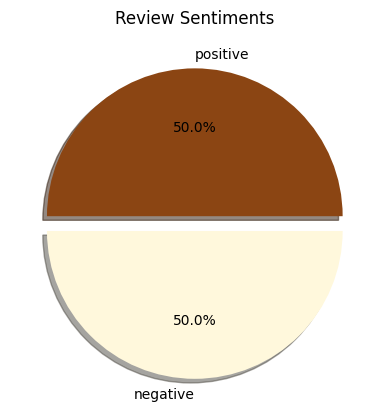

In [ ]:
colors = ('#8B4513', '#FFF8DC')
explode = (0, 0.1)
counts = [25000,25000]

plt.title('Review Sentiments')
plt.pie(counts, labels=df['sentiment'].unique(), autopct='%1.1f%%', colors=colors, explode=explode, shadow=True)
plt.show()

Berdasarkan data yang telah didapat, kedua sentiment memiliki jumlah yang sama, yaitu 25000 sehingga memiliki pembagian yang rata, yaitu 50%.

##Data Preprocessing

In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
contraction_mapping = {
    "ain't": "is not",
    "aren't": "are not",
    "can't": "cannot",
    "could've": "could have",
    "couldn't": "could not",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "gonna": "going to",
    "gotta": "got to",
    "hadn't": "had not",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'll": "he will",
    "he's": "he is",
    "I'd": "I would",
    "I'll": "I will",
    "I'm": "I am",
    "I've": "I have",
    "isn't": "is not",
    "it'd": "it would",
    "it'll": "it will",
    "it's": "it is",
    "let's": "let us",
    "might've": "might have",
    "must've": "must have",
    "mustn't": "must not",
    "needn't": "need not",
    "should've": "should have",
    "shouldn't": "should not",
    "that'd": "that would",
    "that's": "that is",
    "there'd": "there would",
    "there's": "there is",
    "they'd": "they would",
    "they'll": "they will",
    "they're": "they are",
    "they've": "they have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'll": "we will",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'd": "what did",
    "what's": "what is",
    "who'd": "who would",
    "who'll": "who will",
    "who's": "who is",
    "won't": "will not",
    "would've": "would have",
    "wouldn't": "would not",
    "you'd": "you would",
    "you'll": "you will",
    "you're": "you are",
    "you've": "you have"
}

Kami menggunakan beberapa preprocessing yang dibutuhkan saja. Selain itu, urutannya juga penting karena beberapa langkah harus lebih dahulu dari langkah lainnya, contohnya expand contraction harus lebih dahulu daripada remove symbols.

Kami juga menggunakan Lemmatization dibanding stemming karena lebih sesuai konteks.

In [ ]:
def tokenize (df) :
  #Word Tokenization
  df['tokenized_text'] = ''

  for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Tokenizing"):
      text = row['review']
      tokens = word_tokenize(text)
      df.at[index, 'tokenized_text'] = tokens

def preprocess (df) :
  # Convert to lowercase
  df['cleaned_text'] = df['tokenized_text'].apply(lambda tokens: [token.lower() for token in tokens])
  print('convert lowercase done')

  # Expand contraction
  df['cleaned_text'] = df['cleaned_text'].apply(lambda tokens: [contraction_mapping.get(token, token) for token in tokens])
  print('expand contraction done')

  # Remove HTML tags
  df['cleaned_text'] = df['cleaned_text'].apply(lambda tokens: [re.sub('<.*?>', '', token) for token in tokens])
  print ('remove HML tags done')

  # Remove stopwords
  stopwords_list = set(stopwords.words('english'))
  df['cleaned_text'] = df['cleaned_text'].apply(lambda tokens: [token for token in tokens if token.lower() not in stopwords_list])
  print('remove stopword done')

  # Remove symbols
  df['cleaned_text'] = df['cleaned_text'].apply(lambda tokens: [re.sub(r'[^a-zA-Z0-9]', '', token) for token in tokens])
  print('remove symbol done')

  # Convert number
  p = inflect.engine()
  df['converted_text'] = df['cleaned_text'].apply(lambda tokens: [p.number_to_words(token) if token.isdigit() else token for token in tokens])
  print('convert number done')

  # Lemmatization
  lemmatizer = WordNetLemmatizer()
  df['lemmatized_text'] = df['converted_text'].apply(lambda tokens: [lemmatizer.lemmatize(token, wordnet.VERB) for token in tokens])
  print('lemmatization done')

In [ ]:
tokenize(df)

Tokenizing: 100%|██████████| 50000/50000 [01:57<00:00, 424.93it/s]


In [ ]:
preprocess(df)

convert lowercase done
expand contraction done
remove HML tags done
remove stopword done
remove symbol done
convert number done
lemmatization done


In [ ]:
df.head()

,review,sentiment,tokenized_text,cleaned_text,converted_text,lemmatized_text
0,One of the other reviewers has mentioned that ...,positive,"[One, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, 1, oz, e...","[one, reviewers, mentioned, watching, one, oz,...","[one, reviewers, mention, watch, one, oz, epis..."
1,A wonderful little production. <br /><br />The...,positive,"[A, wonderful, little, production, ., <, br, /...","[wonderful, little, production, , , br, , , , ...","[wonderful, little, production, , , br, , , , ...","[wonderful, little, production, , , br, , , , ..."
2,I thought this was a wonderful way to spend ti...,positive,"[I, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su...","[thought, wonderful, way, spend, time, hot, su...","[think, wonderful, way, spend, time, hot, summ..."
3,Basically there's a family where a little boy ...,negative,"[Basically, there, 's, a, family, where, a, li...","[basically, s, family, little, boy, , jake, , ...","[basically, s, family, little, boy, , jake, , ...","[basically, s, family, little, boy, , jake, , ..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"[Petter, Mattei, 's, ``, Love, in, the, Time, ...","[petter, mattei, s, , love, time, money, , vis...","[petter, mattei, s, , love, time, money, , vis...","[petter, mattei, s, , love, time, money, , vis..."


## Classification using TF-IDF Vectorization

In [ ]:
# Split data

vectorizer = TfidfVectorizer()
df['lemmatized_text_str'] = df['lemmatized_text'].apply(lambda tokens: ' '.join(tokens)) #Change back into string for transform

X = vectorizer.fit_transform(df['lemmatized_text_str'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

###Naive Bayes Classification

In [ ]:
# Training model using Naive Bayes
classifier_NB = MultinomialNB()
classifier_NB.fit(X_train, y_train)

y_pred_NB = classifier_NB.predict(X_test)

In [ ]:
# Evalute the model

accuracy_NB = accuracy_score(y_test, y_pred_NB)
precision_NB, recall_NB, fscore_NB, _ = score(y_test, y_pred_NB, average='weighted')
classification_result_NB = classification_report(y_test, y_pred_NB)

print("Accuracy:", accuracy_NB)
print("Precision:", precision_NB)
print("Recall:", recall_NB)
print("F1-score:", fscore_NB)
print()
print("Classification Report:")
print(classification_result_NB)

Accuracy: 0.85945
Precision: 0.8598493433676085
Recall: 0.85945
F1-score: 0.8594140531357687

Classification Report:
              precision    recall  f1-score   support

    negative       0.85      0.88      0.86      9989
    positive       0.87      0.84      0.86     10011

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000



###Random Forest Classfication

In [ ]:
# Create the Random Forest classifier
classifier_RF = RandomForestClassifier()

# Train the classifier
classifier_RF.fit(X_train, y_train)

# Perform predictions on the test set
y_pred_RF = classifier_RF.predict(X_test)

In [ ]:
# Evaluate the classifier
accuracy_RF = accuracy_score(y_test, y_pred_RF)
precision_RF, recall_RF, fscore_RF, _ = score(y_test, y_pred_RF, average='weighted')
classification_result_RF = classification_report(y_test, y_pred_RF)

print("Accuracy:", accuracy_RF)
print("Precision:", precision_RF)
print("Recall:", recall_RF)
print("F1-score:", fscore_RF)
print()
print("Classification Report:")
print(classification_result_RF)

Accuracy: 0.85225
Precision: 0.8522629576045583
Recall: 0.85225
F1-score: 0.8522480219611467

Classification Report:
              precision    recall  f1-score   support

    negative       0.85      0.85      0.85      9989
    positive       0.85      0.86      0.85     10011

    accuracy                           0.85     20000
   macro avg       0.85      0.85      0.85     20000
weighted avg       0.85      0.85      0.85     20000



###LinearSVC Classification

In [ ]:
# Create and train the classifier (LinearSVC)
classifier_SVC = LinearSVC()
classifier_SVC.fit(X_train, y_train)

# Perform predictions on the test set
y_pred_SVC = classifier_SVC.predict(X_test)

# Evaluate the classifier
accuracy_SVC = accuracy_score(y_test, y_pred_SVC)
precision_SVC, recall_SVC, fscore_SVC, _ = score(y_test, y_pred_SVC, average='weighted')
classification_result_SVC = classification_report(y_test, y_pred_SVC)

In [ ]:
# Print the evaluation results
print("Accuracy:", accuracy_SVC)
print("Precision:", precision_SVC)
print("Recall:", recall_SVC)
print("F1-score:", fscore_SVC)
print()
print("Classification Report:")
print(classification_result_SVC)

Accuracy: 0.89255
Precision: 0.8927604828390631
Recall: 0.89255
F1-score: 0.8925340370506482

Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      9989
    positive       0.88      0.90      0.89     10011

    accuracy                           0.89     20000
   macro avg       0.89      0.89      0.89     20000
weighted avg       0.89      0.89      0.89     20000



# Kesimpulan

Dari ketiga algoritma klasifikasi yang digunakan, terlihat bahwa hasil evaluasi tertinggi didapatkan oleh LinearSVC Classfication. Sementara itu, Naive Bayes Classification dan Random Forest Classification tidak memiliki perbedaan signifikan dengan skor hasil evaluasi di antara 0.85-0.86.